In [24]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_gamma_deviance, mean_poisson_deviance, mean_absolute_error, mean_squared_error

# Librerías para visualización gráfica en Python
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo estético para las gráficas
sns.set_theme(style="whitegrid")


ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# --- PREPARACIÓN PARA SEVERIDAD ---
df_sev = pd.read_csv("df_sev_positiva_export.csv")
columnas_categoricas = ['VehBrand', 'VehGas', 'Region']

for col in columnas_categoricas:
    df_sev[col] = df_sev[col].astype('category')

df_sev['LogDensity'] = np.log10(df_sev['Density'] + 1)
df_train_sev, df_test_sev = train_test_split(df_sev, test_size=0.20, random_state=42)

# --- PREPARACIÓN PARA FRECUENCIA ---
df_freq = pd.read_csv("df_completo_export.csv")

for col in columnas_categoricas:
    df_freq[col] = df_freq[col].astype('category')

df_freq['LogDensity'] = np.log10(df_freq['Density'] + 1)
df_freq['ClaimNb'] = df_freq['ClaimNb'].clip(upper=4) # Topamos outliers extremos
df_train_freq, df_test_freq = train_test_split(df_freq, test_size=0.20, random_state=42)

# Definición estándar de características predictivas
features = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'LogDensity', 'VehBrand', 'VehGas']


In [ ]:
formula_sev = "TotalClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + LogDensity + C(VehBrand) + C(VehGas)"

# Uso estricto de .Log() con mayúscula para evitar el FutureWarning
modelo_sev_glm = smf.glm(formula=formula_sev, 
                         data=df_train_sev, 
                         family=sm.families.Gamma(link=sm.families.links.Log()))

resultado_sev_glm = modelo_sev_glm.fit()

print("================ REPORTE GLM SEVERIDAD (GAMMA) ================")
print(resultado_sev_glm.summary())

================ REPORTE GLM SEVERIDAD (GAMMA) ================
                 Generalized Linear Model Regression Results                  
Dep. Variable:       TotalClaimAmount   No. Observations:                19955
Model:                            GLM   Df Residuals:                    19938
Model Family:                   Gamma   Df Model:                           16
Link Function:                    Log   Scale:                          60.600
Method:                          IRLS   Log-Likelihood:            -2.2128e+05
Date:                Sat, 28 Feb 2026   Deviance:                       34046.
Time:                        11:48:15   Pearson chi2:                 1.21e+06
No. Iterations:                    48   Pseudo R-squ. (CS):           0.001606
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

In [ ]:
X_train_sev = df_train_sev[features]
y_train_sev = df_train_sev['TotalClaimAmount']

modelo_sev_hgb = HistGradientBoostingRegressor(
    loss='gamma',
    categorical_features=columnas_categoricas[:2], 
    max_iter=100, 
    learning_rate=0.05,
    random_state=42
)

modelo_sev_hgb.fit(X_train_sev, y_train_sev)

# Emulación de un reporte para el modelo no paramétrico HGB
print("================ REPORTE HGB SEVERIDAD (GAMMA) ================")
print("Estado de convergencia: Entrenamiento finalizado exitosamente.")
print(f"Iteraciones (Árboles construidos): {modelo_sev_hgb.n_iter_} / {modelo_sev_hgb.max_iter}")
print(f"Tasa de aprendizaje (Learning Rate): {modelo_sev_hgb.learning_rate}")
print(f"Profundidad máxima por árbol: {modelo_sev_hgb.max_depth} (Default: Ilimitado)")
print("\nNota Actuarial y Metodológica:")
print("Dado que Scikit-Learn implementa un modelo de ensamble de árboles basado")
print("en particiones ortogonales, no se estiman parámetros lineales (Betas).")
print("Por consiguiente, es matemáticamente imposible calcular errores estándar,")
print("estadísticos Z o P-valores para las variables individuales en este reporte.")

================ REPORTE HGB SEVERIDAD (GAMMA) ================
Estado de convergencia: Entrenamiento finalizado exitosamente.
Iteraciones (Árboles construidos): 16 / 100
Tasa de aprendizaje (Learning Rate): 0.05
Profundidad máxima por árbol: None (Default: Ilimitado)

Nota Actuarial y Metodológica:
Dado que Scikit-Learn implementa un modelo de ensamble de árboles basado
en particiones ortogonales, no se estiman parámetros lineales (Betas).
Por consiguiente, es matemáticamente imposible calcular errores estándar,
estadísticos Z o P-valores para las variables individuales en este reporte.


In [ ]:
X_test_sev = df_test_sev[features]
y_test_sev = df_test_sev['TotalClaimAmount']

pred_s_glm = resultado_sev_glm.predict(df_test_sev)
pred_s_hgb = modelo_sev_hgb.predict(X_test_sev)

def calcular_metricas_severidad(y_real, y_pred, nombre_modelo):
    devianza_gamma = mean_gamma_deviance(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    ratio_equilibrio = np.mean(y_pred) / np.mean(y_real)
    
    return {
        'Modelo': nombre_modelo,
        'Devianza Gamma': devianza_gamma,
        'MAE': mae,
        'RMSE': rmse,
        'Ratio Equilibrio': ratio_equilibrio
    }

met_s_glm = calcular_metricas_severidad(y_test_sev, pred_s_glm, "GLM (Gamma)")
met_s_hgb = calcular_metricas_severidad(y_test_sev, pred_s_hgb, "HistGBM (Gamma)")

df_met_sev = pd.DataFrame([met_s_glm, met_s_hgb])
print("================ MÉTRICAS FUERA DE LA MUESTRA (SEVERIDAD) ================")
print(df_met_sev.to_string(index=False, float_format=lambda x: "{:.4f}".format(x) if isinstance(x, float) else x))

================ MÉTRICAS FUERA DE LA MUESTRA (SEVERIDAD) ================
         Modelo  Devianza Gamma       MAE       RMSE  Ratio Equilibrio
    GLM (Gamma)          1.6408 2319.7153 21227.7672            1.0536
HistGBM (Gamma)          1.6121 2096.5736 21224.2793            0.9291


In [ ]:
formula_freq = "ClaimNb ~ VehPower + VehAge + DrivAge + BonusMalus + LogDensity + C(VehBrand) + C(VehGas)"

# Uso estricto de .Log() con mayúscula para el link de Poisson
modelo_freq_glm = smf.glm(formula=formula_freq, 
                          data=df_train_freq, 
                          family=sm.families.Poisson(link=sm.families.links.Log()),
                          offset=np.log(df_train_freq['Exposure']))

resultado_freq_glm = modelo_freq_glm.fit()

print("================ REPORTE GLM FRECUENCIA (POISSON) ================")
print(resultado_freq_glm.summary())

================ REPORTE GLM FRECUENCIA (POISSON) ================
                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542392
Model:                            GLM   Df Residuals:                   542375
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -86286.
Date:                Sat, 28 Feb 2026   Deviance:                   1.3191e+05
Time:                        11:48:20   Pearson chi2:                 9.20e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01036
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [ ]:
X_train_freq = df_train_freq[features]
y_train_rate = df_train_freq['ClaimNb'] / df_train_freq['Exposure']

modelo_freq_hgb = HistGradientBoostingRegressor(
    loss='poisson',
    categorical_features=columnas_categoricas[:2], 
    max_iter=150, 
    learning_rate=0.05,
    random_state=42
)

modelo_freq_hgb.fit(X_train_freq, y_train_rate, sample_weight=df_train_freq['Exposure'])

# Emulación de un reporte para el modelo no paramétrico HGB
print("================ REPORTE HGB SEVERIDAD (POISSON) ================")
print("Estado de convergencia: Entrenamiento finalizado exitosamente.")
print(f"Iteraciones (Árboles construidos): {modelo_freq_hgb.n_iter_} / {modelo_freq_hgb.max_iter}")
print(f"Tasa de aprendizaje (Learning Rate): {modelo_freq_hgb.learning_rate}")
print(f"Profundidad máxima por árbol: {modelo_freq_hgb.max_depth} (Default: Ilimitado)")

================ REPORTE HGB SEVERIDAD (POISSON) ================
Estado de convergencia: Entrenamiento finalizado exitosamente.
Iteraciones (Árboles construidos): 147 / 150
Tasa de aprendizaje (Learning Rate): 0.05
Profundidad máxima por árbol: None (Default: Ilimitado)


In [ ]:
X_test_freq = df_test_freq[features]
y_test_freq_counts = df_test_freq['ClaimNb']

# GLM: Pasamos el offset explícitamente en la predicción
pred_f_glm = resultado_freq_glm.predict(df_test_freq, offset=np.log(df_test_freq['Exposure']))

# HGB: Predice la tasa (Siniestros/Año). Multiplicamos por Exposición para obtener el conteo.
pred_f_hgb_rate = modelo_freq_hgb.predict(X_test_freq)
pred_f_hgb = pred_f_hgb_rate * df_test_freq['Exposure']

def metricas_frecuencia(y_real, y_pred, exposure, nombre_modelo):
    y_pred_safe = np.clip(y_pred, a_min=1e-8, a_max=None)
    devianza = mean_poisson_deviance(y_real, y_pred_safe)
    
    siniestros_reales = np.sum(y_real)
    siniestros_predichos = np.sum(y_pred)
    ratio_eq = siniestros_predichos / siniestros_reales
    
    exposicion_total = np.sum(exposure)
    freq_real = (siniestros_reales / exposicion_total) * 100
    freq_pred = (siniestros_predichos / exposicion_total) * 100
    
    return {
        'Modelo': nombre_modelo,
        'Devianza Poisson': devianza,
        'Ratio Equilibrio': ratio_eq,
        'Freq. Global Real (%)': freq_real,
        'Freq. Global Pred (%)': freq_pred
    }

met_f_glm = metricas_frecuencia(y_test_freq_counts, pred_f_glm, df_test_freq['Exposure'], "GLM Poisson")
met_f_hgb = metricas_frecuencia(y_test_freq_counts, pred_f_hgb, df_test_freq['Exposure'], "HistGBM Poisson")

df_met_freq = pd.DataFrame([met_f_glm, met_f_hgb])

print("================ MÉTRICAS FUERA DE LA MUESTRA (FRECUENCIA) ================")
print(df_met_freq.to_string(index=False, float_format=lambda x: "{:.4f}".format(x) if isinstance(x, float) else x))

================ MÉTRICAS FUERA DE LA MUESTRA (FRECUENCIA) ================
         Modelo  Devianza Poisson  Ratio Equilibrio  Freq. Global Real (%)  Freq. Global Pred (%)
    GLM Poisson            0.2396            1.0140                 7.2920                 7.3941
HistGBM Poisson            0.2343            1.0181                 7.2920                 7.4240


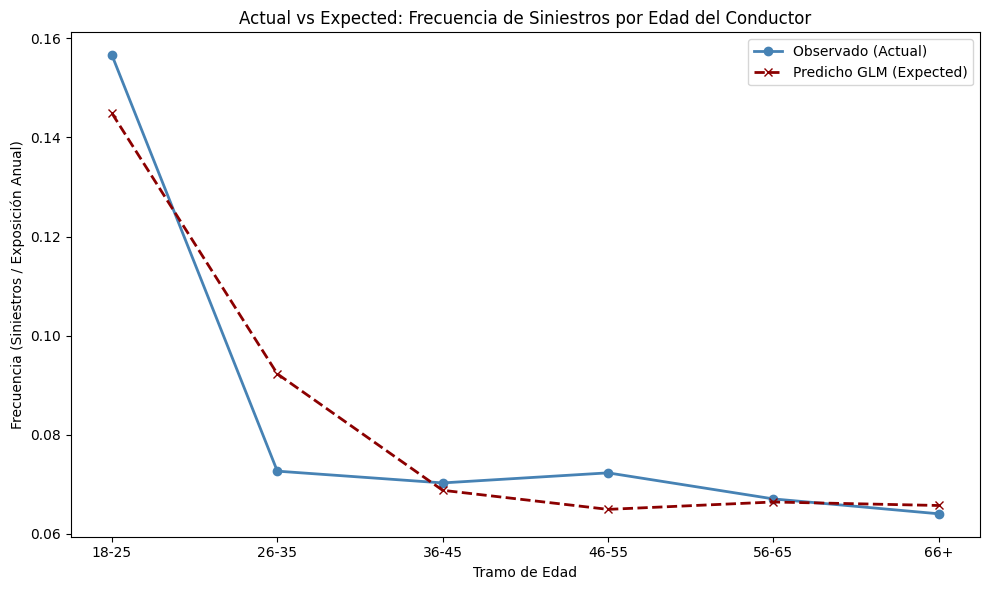

In [25]:
# Copiamos el dataset de prueba y añadimos la predicción del modelo Poisson GLM
df_eval = df_test_freq.copy()
df_eval['Pred_GLM_Count'] = pred_f_glm

# Definimos los tramos (bins) matemáticos para la Edad del Conductor
bins_age = [17, 25, 35, 45, 55, 65, 100]
labels_age = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
df_eval['DrivAge_Band'] = pd.cut(df_eval['DrivAge'], bins=bins_age, labels=labels_age, right=False)

# Agregación actuarial estricta: Sumamos siniestros y exposición a nivel estrato
agrupado_age = df_eval.groupby('DrivAge_Band', observed=False).agg(
    Exposure=('Exposure', 'sum'),
    Actual_Claims=('ClaimNb', 'sum'),
    Expected_Claims=('Pred_GLM_Count', 'sum')
).reset_index()

# Calculamos las frecuencias agregadas
agrupado_age['Actual_Freq'] = agrupado_age['Actual_Claims'] / agrupado_age['Exposure']
agrupado_age['Expected_Freq'] = agrupado_age['Expected_Claims'] / agrupado_age['Exposure']

# Construcción de la visualización
plt.figure(figsize=(10, 6))
plt.plot(agrupado_age['DrivAge_Band'], agrupado_age['Actual_Freq'], marker='o', 
         color='steelblue', linewidth=2, label='Observado (Actual)')
plt.plot(agrupado_age['DrivAge_Band'], agrupado_age['Expected_Freq'], marker='x', 
         color='darkred', linestyle='--', linewidth=2, label='Predicho GLM (Expected)')

plt.title('Actual vs Expected: Frecuencia de Siniestros por Edad del Conductor')
plt.xlabel('Tramo de Edad')
plt.ylabel('Frecuencia (Siniestros / Exposición Anual)')
plt.legend()
plt.tight_layout()
plt.show()

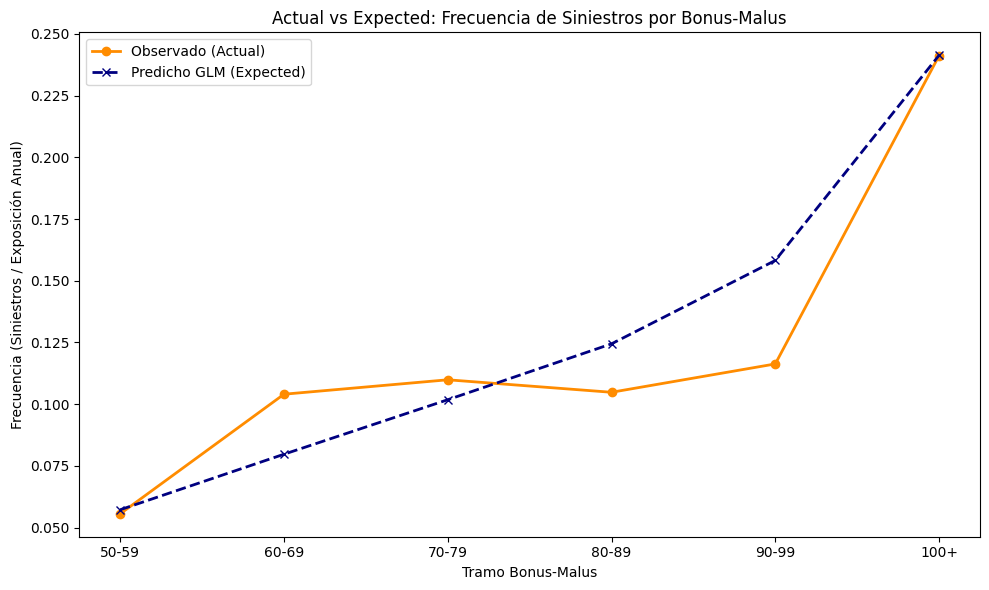

In [26]:
# Definimos los tramos (bins) matemáticos para el nivel BonusMalus
bins_bm = [50, 60, 70, 80, 90, 100, 250]
labels_bm = ['50-59', '60-69', '70-79', '80-89', '90-99', '100+']
df_eval['BM_Band'] = pd.cut(df_eval['BonusMalus'], bins=bins_bm, labels=labels_bm, right=False)

# Agregación actuarial estricta
agrupado_bm = df_eval.groupby('BM_Band', observed=False).agg(
    Exposure=('Exposure', 'sum'),
    Actual_Claims=('ClaimNb', 'sum'),
    Expected_Claims=('Pred_GLM_Count', 'sum')
).reset_index()

# Calculamos las frecuencias agregadas
agrupado_bm['Actual_Freq'] = agrupado_bm['Actual_Claims'] / agrupado_bm['Exposure']
agrupado_bm['Expected_Freq'] = agrupado_bm['Expected_Claims'] / agrupado_bm['Exposure']

# Construcción de la visualización
plt.figure(figsize=(10, 6))
plt.plot(agrupado_bm['BM_Band'], agrupado_bm['Actual_Freq'], marker='o', 
         color='darkorange', linewidth=2, label='Observado (Actual)')
plt.plot(agrupado_bm['BM_Band'], agrupado_bm['Expected_Freq'], marker='x', 
         color='navy', linestyle='--', linewidth=2, label='Predicho GLM (Expected)')

plt.title('Actual vs Expected: Frecuencia de Siniestros por Bonus-Malus')
plt.xlabel('Tramo Bonus-Malus')
plt.ylabel('Frecuencia (Siniestros / Exposición Anual)')
plt.legend()
plt.tight_layout()
plt.show()

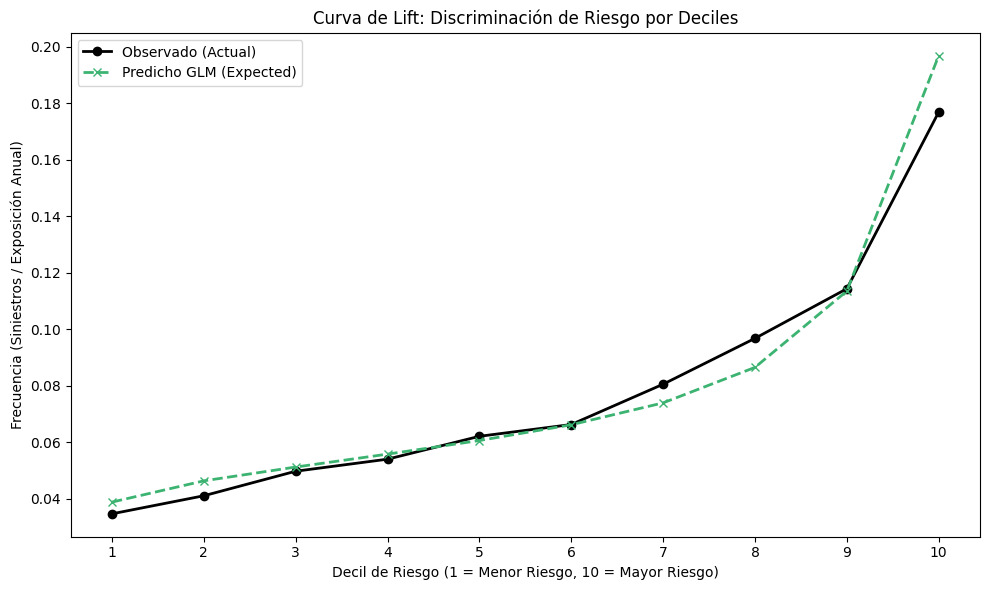

In [29]:
# Paso 1: Calculamos la tasa de siniestralidad predicha (independiente de la exposición)
df_eval['Pred_Rate'] = df_eval['Pred_GLM_Count'] / df_eval['Exposure']

# Paso 2: Ordenamos y agrupamos en 10 deciles (quantile cut)
# Usamos duplicates='drop' en caso de que múltiples pólizas compartan exactamente la misma tasa predictiva.
df_eval['Decile'] = pd.qcut(df_eval['Pred_Rate'], q=10, labels=False, duplicates='drop') + 1

# Paso 3: Agregación actuarial a nivel decil
agrupado_lift = df_eval.groupby('Decile').agg(
    Exposure=('Exposure', 'sum'),
    Actual_Claims=('ClaimNb', 'sum'),
    Expected_Claims=('Pred_GLM_Count', 'sum')
).reset_index()

# Paso 4: Cálculos finales de frecuencia
agrupado_lift['Actual_Freq'] = agrupado_lift['Actual_Claims'] / agrupado_lift['Exposure']
agrupado_lift['Expected_Freq'] = agrupado_lift['Expected_Claims'] / agrupado_lift['Exposure']

# Construcción de la visualización
plt.figure(figsize=(10, 6))
plt.plot(agrupado_lift['Decile'], agrupado_lift['Actual_Freq'], marker='o', 
         color='black', linewidth=2, label='Observado (Actual)')
plt.plot(agrupado_lift['Decile'], agrupado_lift['Expected_Freq'], marker='x', 
         color='mediumseagreen', linestyle='--', linewidth=2, label='Predicho GLM (Expected)')

plt.title('Curva de Lift: Discriminación de Riesgo por Deciles')
plt.xlabel('Decil de Riesgo (1 = Menor Riesgo, 10 = Mayor Riesgo)')
plt.ylabel('Frecuencia (Siniestros / Exposición Anual)')
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()